In [79]:
%reset -f 
%matplotlib inline
import numpy as np
from matplotlib.animation import FuncAnimation
import os, sys, importlib, json, itertools
from datetime import datetime
from IPython.display import HTML, display
import matplotlib.image as mpimg

# Import the aif module
pwd = os.path.abspath('') + "/"
sys.path.insert(1, pwd + '/aif_catkin_ws/aif_gazebo/scripts/simulation_methods')
import aif_functions_isobeliefs_convergent as aif # Interchangeable with aif_functions_isobeliefs and aif_functions_isobeliefs_mcts
# import aif_catkin_ws.aif_gazebo.scripts.aif_functions_isobeliefs_adaptable as aif # Interchangeable with aif_functions_isobeliefs and aif_functions_isobeliefs_mcts
importlib.reload(aif)

import os
print(os.cpu_count())

8


Iteration 30: Agents have selected goals [0, 1]. Execution Time: 0.03771090507507324s Agents have converged to Goal 0 after 30 iterations. Use EP: True
Final Prior:  [array([[0.50967854, 0.49032146],
       [0.50967854, 0.49032146]]), array([[0.50922062, 0.49077938],
       [0.50922062, 0.49077938]])]
Agent Types:  ['A' 'A']


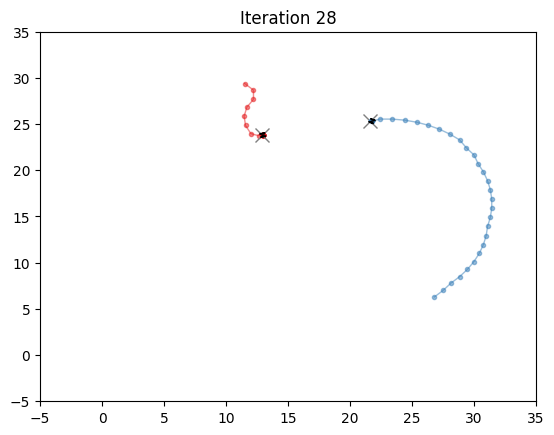

In [80]:
# Re-define the environment and simulation parameters here
interactive = True  # Set to True to display the animation in the notebook
fast_plot = True  # Set to True to use the fast plotter (no icons)
use_ep = True  # Set to True to use EP, False to use the standard algorithm
convergence_type = 'exclusive'  # Set to 'converge' to check for convergence, 'exclusive' to check for separate goals
args = {}
# draft_results = []

random_seed = 27 #39 is good too! 2 goals, 3 agents (actually 39 is perfect)
#2 
#35 is good too! 2 goals, 3 agents --- i use this for the paper converging*
#5 is good too! 3 goals, 3 agents --- i use this for the paper exclusive*

np.random.seed(random_seed)  # Set random seed
# Set random goals
env_size = 30 # Environment size
iterations_per_episode = 150  # Number of iterations per episode
num_goals = 2 # Number of goals
num_agents = 2  # Number of agents
list_types = ['A','B']
goals = np.random.uniform(1,env_size-1,size=(num_goals, 2))  # Goal positions
# goals = np.array([[-2,5], [5,5]], dtype=float)
# goals = np.array([[0,0],[env_size-5,0]], dtype=float)  # Goal positions
# goals = np.array([[0.15, 0.1], [0.5,0.55]])
agent_positions = np.hstack((np.random.uniform(0,env_size,size=(num_agents, 2)),np.zeros((num_agents,1))))  # Initial agent positions
# agent_positions = np.array([[0,0,0],[5,0,0]], dtype=float)
# agent_positions = np.array([[4.45,4.45,-3*np.pi/4],[3.45,3.5,-3*np.pi/4]], dtype=float)
number_of_heading_options = 8; number_of_velocity_options = 4
args = dict({
    'goals': goals, # Goal positions
    'home_base': np.array([0,0]), # Home base position
    'agent_types': np.random.choice(list_types,num_agents),#['A','B','B'],#np.random.choice(list_types,num_agents), # Agent types
    'agent_positions': agent_positions, # Initial agent positions
    'velocity_options': np.linspace(0.0,1,number_of_velocity_options,endpoint=True), # Velocity options
    'num_heading_options': number_of_heading_options, # Number of heading options
    'heading_options': np.linspace(-np.pi/4,np.pi/4,number_of_heading_options,endpoint=True),
    'observation_error_std': 0.5, # Observation error standard deviation
    'num_actions': number_of_heading_options*number_of_velocity_options, # Number of actions
    'env_size': env_size, # Environment size
    'max_distance_measure': env_size + 1,
    'max_heading_measure': np.pi, # Maximum heading measure
    'prior': np.ones(goals.shape[0]) / goals.shape[0], # Prior belief
    'use_ep': use_ep, # Use epistemic planning (2nd order reasoning)
    'greedy': False, # Use greedy action selection
    'horizon': 1, # Horizon for free energy checking
    'mcts_iterations': 100, # Number of MCTS iterations
    'use_mcts': False,
    'use_rhc': False,
    'use_threading': False, #TODO: Implement threading
    'convergence_type': convergence_type, # Convergence type
    'dt': 1., # Time step
})

# Check convergence for different types of conergence criterion
if args['convergence_type'] == 'exclusive':
    tuple_elements = [i for i in range(agent_positions.shape[0])]
    configurations = list(itertools.permutations(tuple_elements))
    args['reward_configs'] = configurations # Reward configurations if different goals
else:
    args['reward_configs'] = [tuple(np.repeat(i, num_agents)) for i in range(num_goals)]

# args['reward_configs'] = [(0,1,1), (1,0,1), (1,1,0)]

# Run the simulation
results = aif.run_simulation(args, iterations_per_episode)
print("Final Prior: ", results['priors'])
print("Agent Types: ", args['agent_types'])


# Create animation
if not fast_plot:
    completed_task_img = mpimg.imread('figures/meeting_icon_selected.png')
    not_completed_task_img = mpimg.imread('figures/meeting_icon_not_selected.png')
    plt_sim = aif.PlotSim(num_agents, goals, args['agent_types'], completed_task_img, not_completed_task_img, env_size, padding=5, scale = 0.3)
else:
    plt_sim = aif.PlotSim_fast(num_agents, goals, args['agent_types'],env_size, padding=5, scale = 0.1)
ani = FuncAnimation(plt_sim.fig, plt_sim.update, frames=range(results['iteration']), init_func=plt_sim.init, fargs = (results['plot_args'],), blit=True, repeat=True)

# Save the animation as a video
current_time = datetime.now().strftime("%Y%m%d-%H%M%S")
config_file = ["numRobots", num_agents, "_numGoals", num_goals, "_seed", random_seed, "_EP", args['use_ep'], "_goalType", convergence_type, "_envSize", env_size]
config_file = ''.join([str(elem) for elem in config_file])
if results['converged'] == None and not interactive:
    filepath = pwd + "videos/NO_convergence_" + config_file + ".mp4"
    ani.save(filepath, writer='ffmpeg', fps=3, dpi=200)
    # Save location of the final image
    print("Image saved as: ", filepath)
elif not interactive:
    filepath = pwd + "videos/Converged_" + config_file + ".mp4"
    ani.save(filepath, writer='ffmpeg', fps=3, dpi=200)
    # Save location of the final image
    print("Image saved as: ", filepath)
else:
    display(HTML(ani.to_jshtml())) # Use an interactive backend for animation



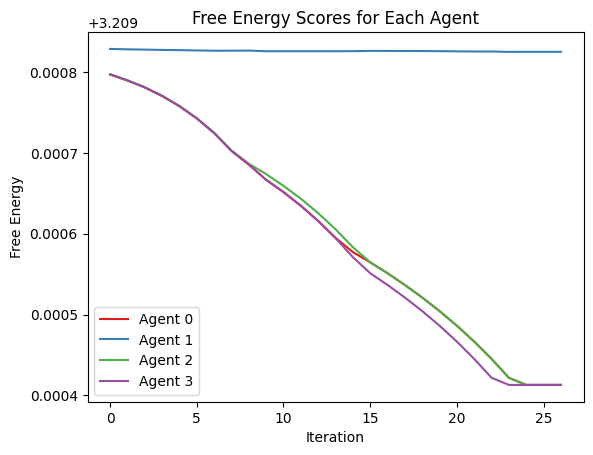

[(0, 1, 2, 3), (0, 1, 3, 2), (0, 2, 1, 3), (0, 2, 3, 1), (0, 3, 1, 2), (0, 3, 2, 1), (1, 0, 2, 3), (1, 0, 3, 2), (1, 2, 0, 3), (1, 2, 3, 0), (1, 3, 0, 2), (1, 3, 2, 0), (2, 0, 1, 3), (2, 0, 3, 1), (2, 1, 0, 3), (2, 1, 3, 0), (2, 3, 0, 1), (2, 3, 1, 0), (3, 0, 1, 2), (3, 0, 2, 1), (3, 1, 0, 2), (3, 1, 2, 0), (3, 2, 0, 1), (3, 2, 1, 0)]


In [9]:
avg_nrg_over_time = results['energy_scores']
num_frames = results['iteration']
energy_results, ending_energy = aif.parse_free_energy_scores(avg_nrg_over_time, num_frames)
aif.plot_energy(energy_results, num_agents)
print(args['reward_configs'])

In [10]:
# Calculate distance to final goals
final_distances = np.zeros((num_agents, goals.shape[0]))
for i in range(num_agents):
    for j in range(goals.shape[0]):
        final_distances[i,j] = np.linalg.norm(results['positions'][i,:2] - goals[j,:])
print("Final distances: ", final_distances)


Final distances:  [[11.91402682 15.91806241  0.06074113  9.71573473]
 [15.06171396 19.75321646  9.63310898  0.1323344 ]
 [ 4.72206845  0.09900113 15.9262513  19.87065155]
 [ 0.16505423  4.71361731 12.0386552  15.12708579]]


In [ ]:
# Scratch code for testing

import numpy as np

def softmax(x):
    """Compute softmax values for each sets of scores in x."""
    if x.ndim == 1:
        x = x.reshape(1, -1) # Convert 1D array to 2D array
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / (np.sum(e_x, axis=1, keepdims=True) + 1e-16)

goals = np.array([[0,0],[0.,10.]])
my_pose = np.array([14.12709979, 12.76192634,  0.])
other_pose = np.array([6.30305407,  7.28140647,  0.])
saliences = np.zeros(goals.shape[0])
goal_azimuths = np.arctan2(goals[:, 1] - my_pose[1], goals[:, 0] - my_pose[0])
observed_azimuth = np.arctan2(other_pose[1] - my_pose[1], other_pose[0] - my_pose[0])
relative_azimuths = np.abs((goal_azimuths - observed_azimuth + np.pi) % (2 * np.pi) - np.pi)
azimuth_salience = softmax(- relative_azimuths / np.pi)  # normalize and invert to make smaller angles more salient
dist_to_goal = np.linalg.norm(goals - my_pose[:2], axis=1)
evidence_to_goal = softmax(-1/30 * dist_to_goal)


saliences += np.squeeze(azimuth_salience)
# Compute if observed robot is heading towards the goal
# heading_to_goal = (np.arctan2(goals[:, 1] - observation['position'][1], goals[:, 0] - observation['position'][0]) - observation['heading'] + np.pi) % (2 * np.pi) - np.pi
# heading_salience = 1./8 * np.exp(- np.abs(heading_to_goal) / np.pi)
# saliences += heading_salience


print("Goal Azimuth: ", goal_azimuths)
print("Relative Azimuth: ", azimuth_salience)
print("Observed Azimuth: ", observed_azimuth)
print("Salience: ", saliences)
print("Distance to Goal: ", dist_to_goal)
print("Evidence to Goal: ", evidence_to_goal)

Goal Azimuth:  [-2.40692159 -2.9485224 ]
Relative Azimuth:  [[0.52340596 0.47659404]]
Observed Azimuth:  -2.5305504167886905
Salience:  [0.52340596 0.47659404]
Distance to Goal:  [19.037902   14.39455403]
Evidence to Goal:  [[0.4613825 0.5386175]]
1.2900073408606396


In [ ]:
poses = np.array([[0,0],[0,0]])+0.5
print(poses)
distance = sum(poses[i][dim] - poses[j][dim] for i in range(2) for j in range(2) if i != j for dim in range(2))
1e4 / (1+np.exp(100*(distance - 1.5)))

[[0.5 0.5]
 [0.5 0.5]]


10000.0